In [9]:
!ls

sample_data


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from google.colab import files

uploaded = files.upload()

Saving holidays_events.csv to holidays_events.csv
Saving oil.csv to oil.csv
Saving sample_submission.csv to sample_submission.csv
Saving stores.csv to stores.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
Saving transactions.csv to transactions.csv


After uploading, you can verify the files are present by running `!ls` again.

In [11]:
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")
test = pd.read_csv("test.csv")

In [12]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [14]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [15]:
oil.isnull().sum()

,0
date,0
dcoilwtico,43


In [16]:
oil = oil.fillna(method="ffill")

/tmp/ipykernel_2202/770133313.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  oil = oil.fillna(method="ffill")


In [17]:
train["date"] = pd.to_datetime(train["date"])
oil["date"] = pd.to_datetime(oil["date"])
transactions["date"] = pd.to_datetime(transactions["date"])

In [18]:
data = train.merge(stores, on="store_nbr", how="left")

In [19]:
data = data.merge(oil, on="date", how="left")

In [20]:
data = data.merge(transactions, on=["date","store_nbr"], how="left")

In [21]:
data.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN


In [22]:
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["dayofweek"] = data["date"].dt.dayofweek

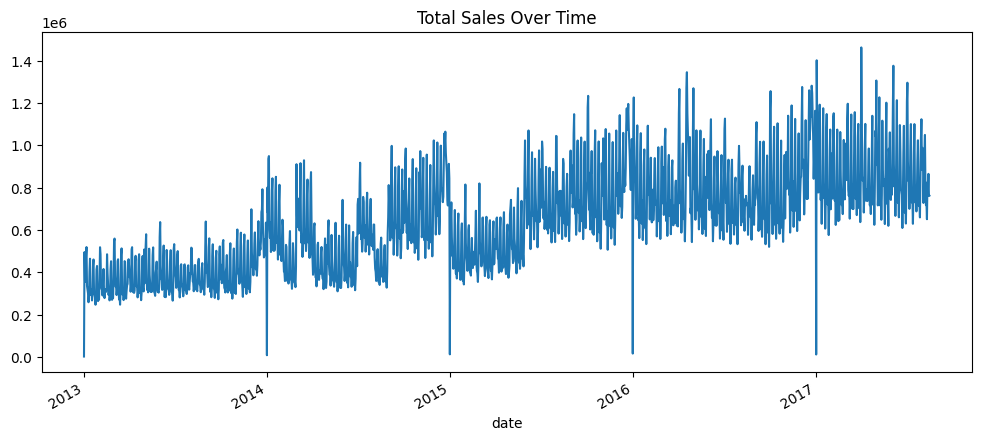

In [23]:
sales_trend = data.groupby("date")["sales"].sum()

plt.figure(figsize=(12,5))
sales_trend.plot()
plt.title("Total Sales Over Time")
plt.show()

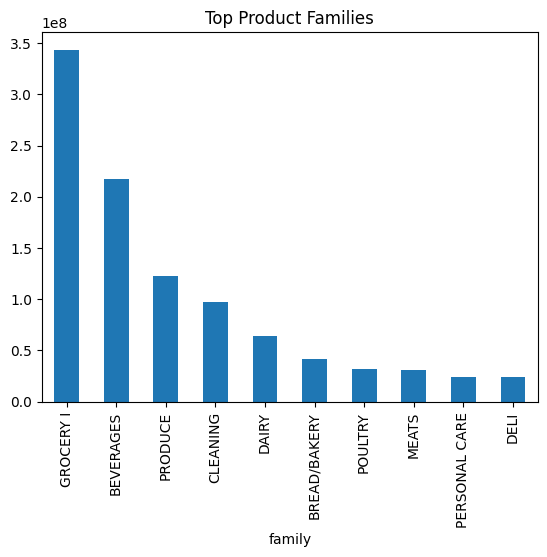

In [24]:
top_products = data.groupby("family")["sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top Product Families")
plt.show()

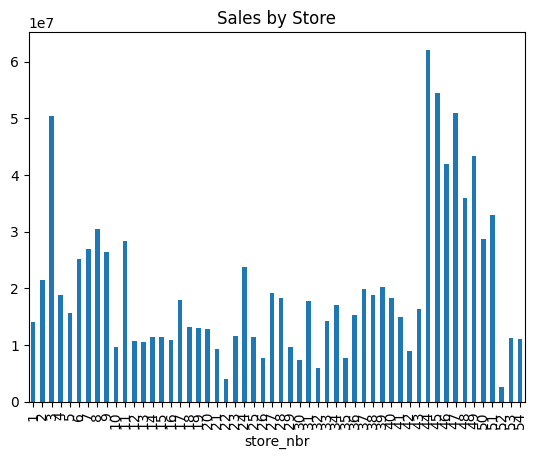

In [25]:
store_sales = data.groupby("store_nbr")["sales"].sum()

store_sales.plot(kind="bar")
plt.title("Sales by Store")
plt.show()

In [26]:
features = ["store_nbr","month","dayofweek","onpromotion"]

X = data[features]
y = data["sales"]

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train,y_train)

RandomForestRegressor()

In [29]:
predictions = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)

print("MAE:",mae)

MAE: 357.4085265656568


In [31]:
future_data = [[1,12,5,3]]

prediction = model.predict(future_data)

print("Predicted Sales:", prediction)

Predicted Sales: [636.1067077]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Store 1
Month December
Saturday
3 items on promotion

In [32]:
import pickle

pickle.dump(model,open("sales_forecast_model.pkl","wb"))